# CNN evaluation HDF5 demo

This notebook evaluates CNN prediction files generated by:

```bash
python cbc_pe/scripts/train_cnn_hdf5.py --config <config.json>
```

The current goal is to compare candidate CNN architectures trained on the 100k HDF5 dataset using the 80/20 train/validation split.

This notebook focuses on:

- global validation metrics
- per-label validation metrics
- standardized-space metrics
- physical-space metrics
- absolute-error quantiles
- detailed diagnostics for a selected model

In [15]:
from pathlib import Path
import os
import sys
import json

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# Allow running either from repository root or from cbc_pe/.
if PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Main data root for CIEMAT/local office workflow.
DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")

DATA_PROCESSED = DATA_ROOT / "processed"
DATA_RESULTS = DATA_ROOT / "results"
DATA_MODELS = DATA_ROOT / "models"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
MODEL_RESULTS_DIR = DATA_RESULTS / dataset_id

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("MODEL_RESULTS_DIR:", MODEL_RESULTS_DIR)
print("MODEL_RESULTS_DIR exists:", MODEL_RESULTS_DIR.exists())

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
DATA_ROOT: /scratch/vserrano/cbc_pe_data
DATA_PROCESSED: /scratch/vserrano/cbc_pe_data/processed
MODEL_RESULTS_DIR: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000
MODEL_RESULTS_DIR exists: True


## Register models to compare

Add one entry per trained model.

When a new model finishes training, add its prediction file to `prediction_files` and re-run the comparison cells.

In [16]:
prediction_files = {
    "M00_baseline_emb64_seed123": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed124": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed125": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed125"
        "_train_val_predictions_embeddings.npz"
    ),
    "M01_pool1_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M01_emb128_pool1_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M02_pool4_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M02_emb128_pool4_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_dropout020_wd1e3_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4_drop_wd": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M06_WideCNN_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_WideCNN_Pool_M06_emb128_pool4_widecnn_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
}



for model_id, path in prediction_files.items():
    print(f"{model_id:30s} exists={path.exists()}  file={path.name}")

M00_baseline_emb64_seed123     exists=True  file=bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
M00_baseline_emb64_seed124     exists=True  file=bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124_train_val_predictions_embeddings.npz
M00_baseline_emb64_seed125     exists=True  file=bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed125_train_val_predictions_embeddings.npz
M01_pool1_emb128               exists=True  file=bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Pool_M01_emb128_pool1_MSELoss_seed123_train_val_predictions_embeddings.npz
M02_pool4_emb128               exists=True  file=bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Pool_M02_emb128_pool4_MSELoss_seed123_train_val_predictions_embeddings.npz
M04_pooldeep_emb128_pool4      exists=True  file=bbh_processed_4s_seobn

## Metric helper functions

In [17]:
def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    global_mse = np.mean(residual**2)
    global_rmse = np.sqrt(global_mse)
    global_mae = np.mean(np.abs(residual))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": global_mse,
        "global_rmse": global_rmse,
        "global_mae": global_mae,
    }


def abs_error_quantiles(y_true, y_pred, label_names, model_id, space):
    abs_err = np.abs(y_true - y_pred)
    rows = []

    for j, label in enumerate(label_names):
        q50, q90, q95, q99 = np.quantile(abs_err[:, j], [0.50, 0.90, 0.95, 0.99])

        rows.append({
            "model_id": model_id,
            "space": space,
            "label": label,
            "q50_abs_error": q50,
            "q90_abs_error": q90,
            "q95_abs_error": q95,
            "q99_abs_error": q99,
            "max_abs_error": abs_err[:, j].max(),
        })

    return rows


def get_label_names(data):
    if "label_names" in data.files:
        return [str(x) for x in data["label_names"].tolist()]
    return ["chirp_mass", "total_mass", "chi_eff"]

## Compute validation metrics for all models

Metrics are computed in:

- standardized space
- physical space

In [18]:
metric_rows = []
quantile_rows = []

for model_id, path in prediction_files.items():
    if not path.exists():
        print(f"Skipping missing file: {model_id} -> {path}")
        continue

    data = np.load(path, allow_pickle=True)

    pred_val = data["pred_val"]
    y_val = data["y_val"]

    y_mean = data["y_mean"]
    y_std = data["y_std"]
    label_names = get_label_names(data)

    # -------------------------
    # Standardized space
    # -------------------------
    metrics_std = regression_metrics(y_val, pred_val)

    metric_rows.append({
        "model_id": model_id,
        "space": "standardized",
        "label": "global",
        "MSE": metrics_std["global_mse"],
        "RMSE": metrics_std["global_rmse"],
        "MAE": metrics_std["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "standardized",
            "label": label,
            "MSE": metrics_std["mse"][j],
            "RMSE": metrics_std["rmse"][j],
            "MAE": metrics_std["mae"][j],
            "Bias": metrics_std["bias"][j],
            "Residual std": metrics_std["residual_std"][j],
            "R2": metrics_std["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val,
            y_pred=pred_val,
            label_names=label_names,
            model_id=model_id,
            space="standardized",
        )
    )

    # -------------------------
    # Physical space
    # -------------------------
    y_val_phys = y_val * y_std + y_mean
    pred_val_phys = pred_val * y_std + y_mean

    metrics_phys = regression_metrics(y_val_phys, pred_val_phys)

    metric_rows.append({
        "model_id": model_id,
        "space": "physical",
        "label": "global",
        "MSE": metrics_phys["global_mse"],
        "RMSE": metrics_phys["global_rmse"],
        "MAE": metrics_phys["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "physical",
            "label": label,
            "MSE": metrics_phys["mse"][j],
            "RMSE": metrics_phys["rmse"][j],
            "MAE": metrics_phys["mae"][j],
            "Bias": metrics_phys["bias"][j],
            "Residual std": metrics_phys["residual_std"][j],
            "R2": metrics_phys["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val_phys,
            y_pred=pred_val_phys,
            label_names=label_names,
            model_id=model_id,
            space="physical",
        )
    )

summary_df = pd.DataFrame(metric_rows)
quantiles_df = pd.DataFrame(quantile_rows)

summary_df

,model_id,space,label,MSE,RMSE,MAE,Bias,Residual std,R2
0,M00_baseline_emb64_seed123,standardized,global,0.177084,0.420813,0.305378,NaN,NaN,NaN
1,M00_baseline_emb64_seed123,standardized,chirp_mass,0.140808,0.375244,0.268875,-0.013185,0.375013,0.857300
2,M00_baseline_emb64_seed123,standardized,total_mass,0.112468,0.335363,0.249743,-0.009372,0.335232,0.885663
3,M00_baseline_emb64_seed123,standardized,chi_eff,0.277973,0.527231,0.397517,-0.007467,0.527178,0.725214
4,M00_baseline_emb64_seed123,physical,global,58.075588,7.620734,4.431233,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
59,M06_WideCNN_emb128_pool4,standardized,chi_eff,0.283660,0.532597,0.405834,-0.004616,0.532578,0.719592
60,M06_WideCNN_emb128_pool4,physical,global,59.496357,7.713388,4.506614,NaN,NaN,NaN
61,M06_WideCNN_emb128_pool4,physical,chirp_mass,39.349358,6.272907,4.527555,0.317423,6.264858,0.854007
62,M06_WideCNN_emb128_pool4,physical,total_mass,139.084747,11.793420,8.813968,0.472019,11.783961,0.882820


## Global validation metrics

In [19]:
summary_df.query("space == 'standardized' and label == 'global'").sort_values("MSE")

,model_id,space,label,MSE,RMSE,MAE,Bias,Residual std,R2
8,M00_baseline_emb64_seed124,standardized,global,0.173310,0.416305,0.303117,NaN,NaN,NaN
16,M00_baseline_emb64_seed125,standardized,global,0.173485,0.416515,0.302875,NaN,NaN,NaN
48,M04_pooldeep_emb128_pool4_drop_wd,standardized,global,0.176160,0.419714,0.305510,NaN,NaN,NaN
0,M00_baseline_emb64_seed123,standardized,global,0.177084,0.420813,0.305378,NaN,NaN,NaN
24,M01_pool1_emb128,standardized,global,0.178520,0.422516,0.310376,NaN,NaN,NaN
56,M06_WideCNN_emb128_pool4,standardized,global,0.180994,0.425434,0.311171,NaN,NaN,NaN
40,M04_pooldeep_emb128_pool4,standardized,global,0.182728,0.427467,0.312132,NaN,NaN,NaN
32,M02_pool4_emb128,standardized,global,0.182914,0.427684,0.315345,NaN,NaN,NaN


## Per-label validation metrics: standardized space

In [20]:
summary_df.query("space == 'standardized' and label != 'global'").sort_values(["label", "MSE"])

,model_id,space,label,MSE,RMSE,MAE,Bias,Residual std,R2
19,M00_baseline_emb64_seed125,standardized,chi_eff,0.271617,0.521169,0.394862,0.009106,0.521089,0.731497
11,M00_baseline_emb64_seed124,standardized,chi_eff,0.275001,0.524405,0.397182,0.017485,0.524114,0.728152
3,M00_baseline_emb64_seed123,standardized,chi_eff,0.277973,0.527231,0.397517,-0.007467,0.527178,0.725214
27,M01_pool1_emb128,standardized,chi_eff,0.279148,0.528344,0.401955,-0.000254,0.528344,0.724053
51,M04_pooldeep_emb128_pool4_drop_wd,standardized,chi_eff,0.279810,0.528971,0.400771,-0.038120,0.527596,0.723398
59,M06_WideCNN_emb128_pool4,standardized,chi_eff,0.283660,0.532597,0.405834,-0.004616,0.532578,0.719592
35,M02_pool4_emb128,standardized,chi_eff,0.283983,0.532901,0.406288,-0.014028,0.532716,0.719272
43,M04_pooldeep_emb128_pool4,standardized,chi_eff,0.291615,0.540014,0.412341,-0.023142,0.539518,0.711728
9,M00_baseline_emb64_seed124,standardized,chirp_mass,0.136253,0.369125,0.266263,0.003366,0.369111,0.861916
49,M04_pooldeep_emb128_pool4_drop_wd,standardized,chirp_mass,0.137081,0.370245,0.264898,-0.019893,0.369710,0.861077


## Per-label validation metrics: physical space

In [21]:
summary_df.query("space == 'physical' and label != 'global'").sort_values(["label", "RMSE"])

,model_id,space,label,MSE,RMSE,MAE,Bias,Residual std,R2
23,M00_baseline_emb64_seed125,physical,chi_eff,0.052435,0.228988,0.173492,0.004001,0.228953,0.731499
15,M00_baseline_emb64_seed124,physical,chi_eff,0.053089,0.230410,0.174512,0.007683,0.230282,0.728152
7,M00_baseline_emb64_seed123,physical,chi_eff,0.053663,0.231652,0.174658,-0.003281,0.231628,0.725214
31,M01_pool1_emb128,physical,chi_eff,0.053890,0.232141,0.176609,-0.000112,0.232141,0.724053
55,M04_pooldeep_emb128_pool4_drop_wd,physical,chi_eff,0.054017,0.232416,0.176089,-0.016749,0.231812,0.723399
63,M06_WideCNN_emb128_pool4,physical,chi_eff,0.054760,0.234009,0.178313,-0.002028,0.234001,0.719593
39,M02_pool4_emb128,physical,chi_eff,0.054823,0.234143,0.178512,-0.006164,0.234062,0.719274
47,M04_pooldeep_emb128_pool4,physical,chi_eff,0.056296,0.237268,0.181171,-0.010168,0.237050,0.711730
13,M00_baseline_emb64_seed124,physical,chirp_mass,37.217842,6.100643,4.400578,0.055626,6.100387,0.861915
53,M04_pooldeep_emb128_pool4_drop_wd,physical,chirp_mass,37.443871,6.119140,4.378024,-0.328783,6.110294,0.861076


## Absolute-error quantiles

These are useful for checking whether a model improves only the mean error or also the tails.

In [22]:
quantiles_df.query("space == 'physical'").sort_values(["label", "q90_abs_error"])

,model_id,space,label,q50_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,max_abs_error
11,M00_baseline_emb64_seed124,physical,chi_eff,0.137851,0.369708,0.461088,0.706991,1.348988
17,M00_baseline_emb64_seed125,physical,chi_eff,0.135413,0.370153,0.467297,0.697376,1.253092
5,M00_baseline_emb64_seed123,physical,chi_eff,0.135971,0.372139,0.470430,0.699990,1.240961
41,M04_pooldeep_emb128_pool4_drop_wd,physical,chi_eff,0.138944,0.373626,0.470482,0.702085,1.370715
29,M02_pool4_emb128,physical,chi_eff,0.142903,0.376776,0.469615,0.702590,1.301121
23,M01_pool1_emb128,physical,chi_eff,0.138833,0.376889,0.470462,0.706640,1.237622
47,M06_WideCNN_emb128_pool4,physical,chi_eff,0.140824,0.379565,0.473969,0.695894,1.190920
35,M04_pooldeep_emb128_pool4,physical,chi_eff,0.144641,0.381040,0.479900,0.694486,1.217814
9,M00_baseline_emb64_seed124,physical,chirp_mass,3.181292,9.709856,12.746800,19.824080,43.950905
39,M04_pooldeep_emb128_pool4_drop_wd,physical,chirp_mass,3.122549,9.802851,12.835625,20.175450,42.034042


## Save comparison tables

In [23]:
comparison_dir = MODEL_RESULTS_DIR / "evaluation"
comparison_dir.mkdir(parents=True, exist_ok=True)

summary_csv = comparison_dir / "architecture_search_val_metrics.csv"
quantiles_csv = comparison_dir / "architecture_search_val_abs_error_quantiles.csv"

summary_df.to_csv(summary_csv, index=False)
quantiles_df.to_csv(quantiles_csv, index=False)

print("Saved:", summary_csv)
print("Saved:", quantiles_csv)

Saved: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/evaluation/architecture_search_val_metrics.csv
Saved: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/evaluation/architecture_search_val_abs_error_quantiles.csv


## Detailed diagnostics for one selected model

Use this section to inspect residuals, prediction-vs-truth plots, SNR dependence, and embedding behavior for one model.

Do not run detailed plots for every model unless the summary tables justify it.

In [24]:
SELECTED_MODEL_ID = "M00_baseline_emb64_seed123"
# SELECTED_MODEL_ID = "M01_pool1_emb128"
# SELECTED_MODEL_ID = "M02_pool4_emb128"
# SELECTED_MODEL_ID = "M04_pooldeep_emb128_pool4"

selected_path = prediction_files[SELECTED_MODEL_ID]

data = np.load(selected_path, allow_pickle=True)

pred_train = data["pred_train"]
y_train = data["y_train"]
emb_train = data["emb_train"]

pred_val = data["pred_val"]
y_val = data["y_val"]
emb_val = data["emb_val"]

y_mean = data["y_mean"]
y_std = data["y_std"]
label_names = get_label_names(data)

# Robust index loading across script versions.
train_idx = data["idx_train"] if "idx_train" in data.files else data["train_idx"]
val_idx = data["idx_val"] if "idx_val" in data.files else data["val_idx"]

pred_val_phys = pred_val * y_std + y_mean
y_val_phys = y_val * y_std + y_mean
residual_val_phys = y_val_phys - pred_val_phys

print("Selected model:", SELECTED_MODEL_ID)
print("prediction file:", selected_path)
print("label_names:", label_names)
print("pred_val:", pred_val.shape)
print("y_val:", y_val.shape)
print("emb_val:", emb_val.shape)
print("val_idx:", val_idx.shape)

Selected model: M00_baseline_emb64_seed123
prediction file: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
label_names: ['chirp_mass', 'total_mass', 'chi_eff']
pred_val: (20000, 3)
y_val: (20000, 3)
emb_val: (20000, 64)
val_idx: (20000,)


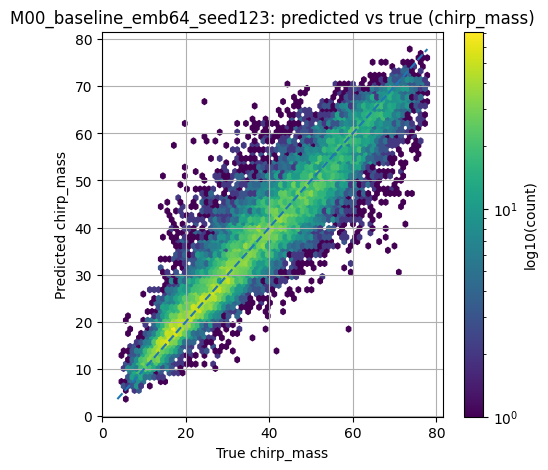

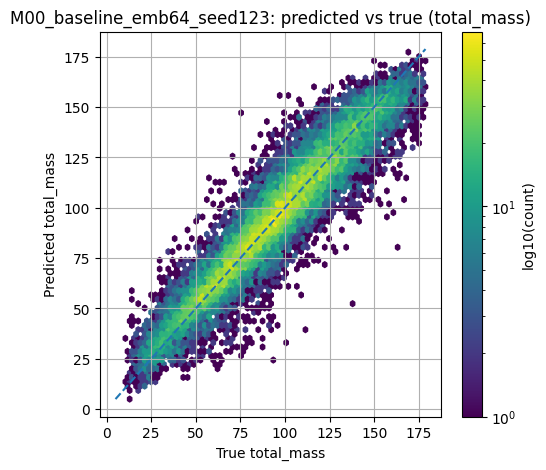

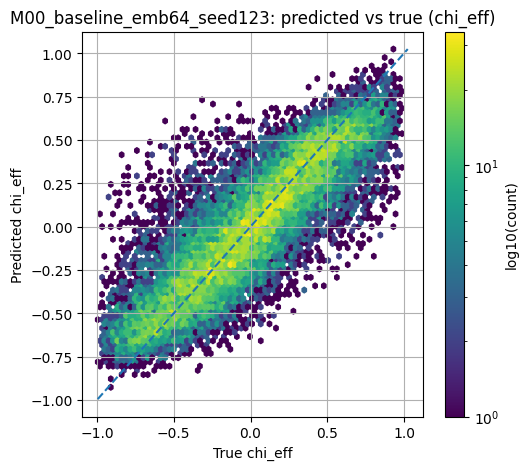

In [25]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    pred = pred_val_phys[:, j]

    plt.figure(figsize=(5.5, 5))
    hb = plt.hexbin(true, pred, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")

    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"{SELECTED_MODEL_ID}: predicted vs true ({label})")
    plt.grid(True)
    plt.show()

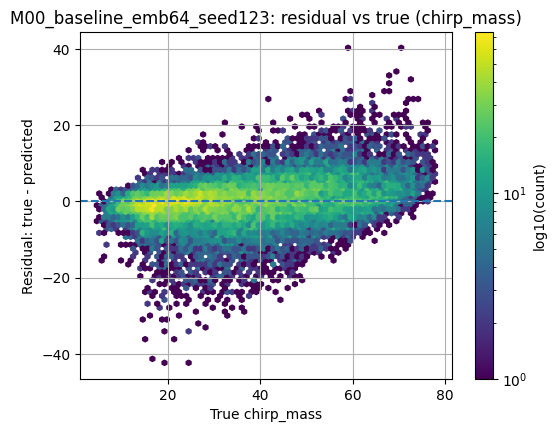

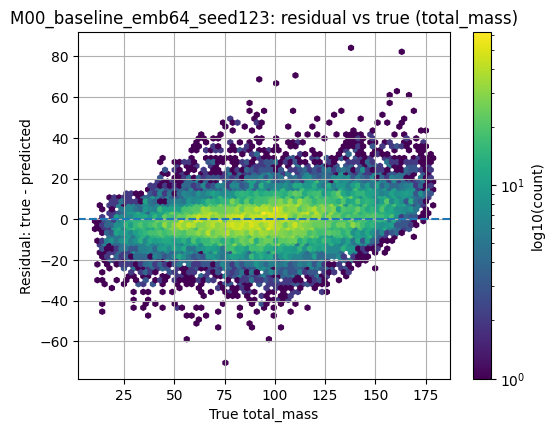

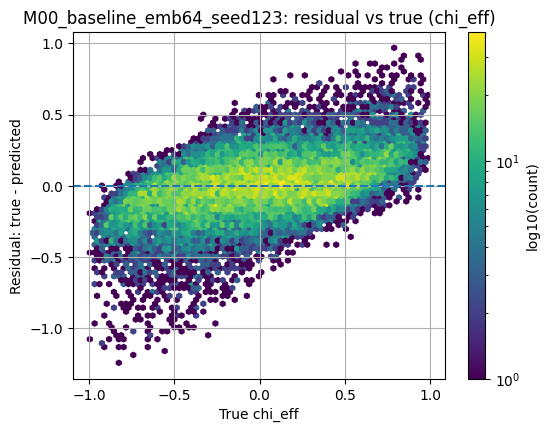

In [26]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    residual = residual_val_phys[:, j]

    plt.figure(figsize=(6, 4.5))
    hb = plt.hexbin(true, residual, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    plt.axhline(0.0, linestyle="--")
    plt.xlabel(f"True {label}")
    plt.ylabel("Residual: true - predicted")
    plt.title(f"{SELECTED_MODEL_ID}: residual vs true ({label})")
    plt.grid(True)
    plt.show()

## Comparison between models

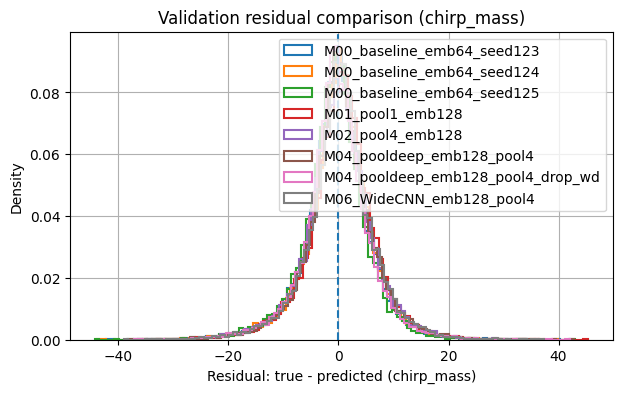

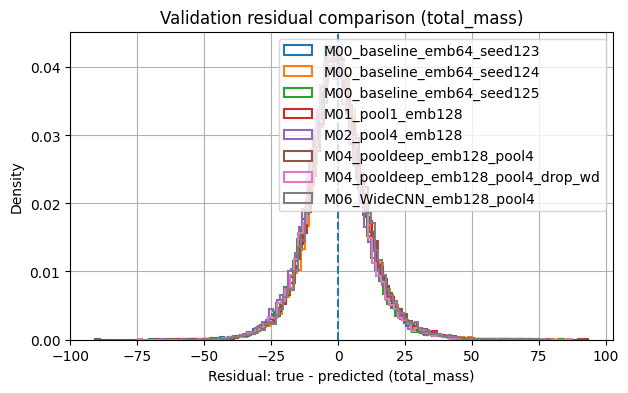

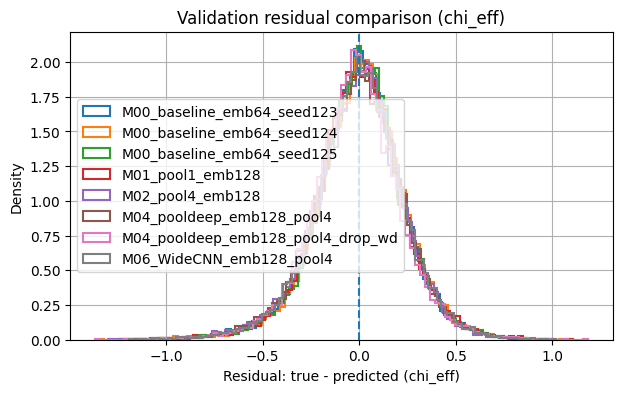

In [27]:
for label_idx, label in enumerate(label_names):
    plt.figure(figsize=(7, 4))

    for model_id, path in prediction_files.items():
        if not path.exists():
            continue

        data = np.load(path, allow_pickle=True)
        pred_val = data["pred_val"]
        y_val = data["y_val"]
        y_mean = data["y_mean"]
        y_std = data["y_std"]

        pred_phys = pred_val * y_std + y_mean
        y_phys = y_val * y_std + y_mean
        residual = y_phys[:, label_idx] - pred_phys[:, label_idx]

        plt.hist(
            residual,
            bins=100,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=model_id,
        )

    plt.axvline(0.0, linestyle="--")
    plt.xlabel(f"Residual: true - predicted ({label})")
    plt.ylabel("Density")
    plt.title(f"Validation residual comparison ({label})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Version 2.0 (overfitting inspection)

## Imports and Paths

In [28]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajusta si tus rutas tienen otro nombre en el notebook
# Por ejemplo:
DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")
RESULTS_DIR = DATA_ROOT / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
CHECKPOINTS_DIR = DATA_ROOT / "models" / "checkpoints" / "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"

RESULTS_DIR = Path(RESULTS_DIR)
CHECKPOINTS_DIR = Path(CHECKPOINTS_DIR)

print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("CHECKPOINTS_DIR exists:", CHECKPOINTS_DIR.exists())

RESULTS_DIR: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000
CHECKPOINTS_DIR: /scratch/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000
RESULTS_DIR exists: True
CHECKPOINTS_DIR exists: True


## Load predictions and histories

In [29]:
prediction_paths = sorted(RESULTS_DIR.glob("*predictions_embeddings.npz"))
history_paths = sorted(RESULTS_DIR.glob("*history.npz"))

print(f"Prediction files found: {len(prediction_paths)}")
for p in prediction_paths:
    print("  ", p.name)

print()
print(f"History files found: {len(history_paths)}")
for p in history_paths:
    print("  ", p.name)

Prediction files found: 8
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed125_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_dropout020_wd1e3_MSELoss_seed123_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Pool_M01_emb128_pool1_MSELoss_seed123_train_val_predictions_embeddings.npz
   bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Pool_M02_emb128_pool4_MSELoss_seed123

In [30]:
# Build model-file table using the manual prediction_files dictionary.
# This avoids confusing architecture_name with the experimental model_id.

def prediction_to_history_path(pred_path, results_dir):
    """
    Reconstruct the history path from the prediction file path.

    Training script saves:
        *_history.npz

    Prediction script saves:
        *_train_val_predictions_embeddings.npz
        or other split suffixes.
    """
    pred_path = Path(pred_path)
    name = pred_path.name

    suffixes = [
        "_train_val_predictions_embeddings.npz",
        "_train_val_cal_test_predictions_embeddings.npz",
        "_train_val_cal_predictions_embeddings.npz",
        "_train_val_test_predictions_embeddings.npz",
    ]

    for suffix in suffixes:
        if name.endswith(suffix):
            base = name.replace(suffix, "")
            return Path(results_dir) / f"{base}_history.npz"

    raise ValueError(f"Could not infer history path from: {name}")


def load_model_config_from_prediction(pred_path):
    pred_path = Path(pred_path)

    if not pred_path.exists():
        return {}

    with np.load(pred_path, allow_pickle=True) as data:
        if "model_config" not in data.files:
            return {}

        obj = data["model_config"]

        try:
            return obj.item()
        except Exception:
            return {}


model_file_rows = []

for model_id, pred_path in prediction_files.items():
    pred_path = Path(pred_path)
    hist_path = prediction_to_history_path(pred_path, MODEL_RESULTS_DIR)

    model_config = load_model_config_from_prediction(pred_path)

    if pred_path.exists():
        with np.load(pred_path, allow_pickle=True) as data:
            available_splits = (
                data["available_splits"].tolist()
                if "available_splits" in data.files
                else []
            )
            label_names_in_file = (
                data["label_names"].tolist()
                if "label_names" in data.files
                else ["chirp_mass", "total_mass", "chi_eff"]
            )
    else:
        available_splits = []
        label_names_in_file = []

    model_file_rows.append({
        "model_id": model_id,  # IMPORTANT: manual experimental ID
        "architecture": model_config.get("architecture", None),
        "class_name": model_config.get("class_name", None),
        "model_kwargs": model_config.get("model_kwargs", None),
        "prediction_file": pred_path.name,
        "prediction_path": pred_path,
        "prediction_exists": pred_path.exists(),
        "history_file": hist_path.name,
        "history_path": hist_path,
        "history_exists": hist_path.exists(),
        "available_splits": available_splits,
        "label_names": label_names_in_file,
    })

model_files_df = (
    pd.DataFrame(model_file_rows)
    .sort_values("model_id")
    .reset_index(drop=True)
)

model_files_df

,model_id,architecture,class_name,model_kwargs,prediction_file,prediction_path,prediction_exists,history_file,history_path,history_exists,available_splits,label_names
0,M00_baseline_emb64_seed123,None,None,None,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,[],"[chirp_mass, total_mass, chi_eff]"
1,M00_baseline_emb64_seed124,SimpleCNN_Baseline,SimpleCNN_Baseline,"{'embedding_dim': 64, 'dropout_conv': 0.05, 'd...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
2,M00_baseline_emb64_seed125,SimpleCNN_Baseline,SimpleCNN_Baseline,"{'embedding_dim': 64, 'dropout_conv': 0.05, 'd...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
3,M01_pool1_emb128,SimpleCNN_Pool,SimpleCNN_Pool,"{'embedding_dim': 128, 'dropout_conv': 0.05, '...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
4,M02_pool4_emb128,SimpleCNN_Pool,SimpleCNN_Pool,"{'embedding_dim': 128, 'dropout_conv': 0.05, '...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
5,M04_pooldeep_emb128_pool4,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,"{'embedding_dim': 128, 'dropout_conv': 0.1, 'd...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
6,M04_pooldeep_emb128_pool4_drop_wd,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,"{'embedding_dim': 128, 'dropout_conv': 0.05, '...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"
7,M06_WideCNN_emb128_pool4,M06_WideCNN_emb128_pool4,WideCNN_Pool,"{'embedding_dim': 128, 'dropout_conv': 0.05, '...",bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,/scratch/vserrano/cbc_pe_data/results/bbh_proc...,True,"[train, val]","[chirp_mass, total_mass, chi_eff]"


In [31]:
def load_history_npz(history_path):
    history_path = Path(history_path)

    if not history_path.exists():
        return None

    with np.load(history_path, allow_pickle=True) as data:
        files = list(data.files)

        if "train_loss" in files and "val_loss" in files:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

        elif "history" in files:
            obj = data["history"].tolist()

            if isinstance(obj, dict):
                history_df = pd.DataFrame(obj)
            elif isinstance(obj, list):
                history_df = pd.DataFrame(obj)
            else:
                raise ValueError(f"Unsupported history object in {history_path}")

        else:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

    history_df = history_df.rename(columns={
        "train": "train_loss",
        "val": "val_loss",
        "valid_loss": "val_loss",
        "validation_loss": "val_loss",
    })

    if "epoch" not in history_df.columns:
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    return history_df

In [32]:
def summarize_history(history_df):
    h = history_df.copy()

    required = {"epoch", "train_loss", "val_loss"}
    missing = required - set(h.columns)

    if missing:
        raise ValueError(
            f"Missing columns {missing}. Available columns: {h.columns.tolist()}"
        )

    h["train_loss"] = h["train_loss"].astype(float)
    h["val_loss"] = h["val_loss"].astype(float)

    best_idx = h["val_loss"].idxmin()

    best_epoch = int(h.loc[best_idx, "epoch"])
    stop_epoch = int(h["epoch"].iloc[-1])

    best_val_loss = float(h.loc[best_idx, "val_loss"])
    train_loss_at_best = float(h.loc[best_idx, "train_loss"])

    final_train_loss = float(h["train_loss"].iloc[-1])
    final_val_loss = float(h["val_loss"].iloc[-1])

    return {
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "epochs_after_best": stop_epoch - best_epoch,
        "best_val_loss": best_val_loss,
        "train_loss_at_best": train_loss_at_best,
        "gap_at_best": best_val_loss - train_loss_at_best,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "final_gap": final_val_loss - final_train_loss,
        "min_train_loss": float(h["train_loss"].min()),
        "min_val_loss": float(h["val_loss"].min()),
    }


history_rows = []

for _, row in model_files_df.iterrows():
    if not row["history_exists"]:
        print(f"Skipping {row['model_id']}: no history found")
        continue

    h = load_history_npz(row["history_path"])

    try:
        summary = summarize_history(h)
        summary["model_id"] = row["model_id"]
        summary["architecture"] = row["architecture"]
        summary["class_name"] = row["class_name"]
        summary["history_file"] = row["history_file"]
        history_rows.append(summary)

    except Exception as e:
        print(f"Could not summarize {row['model_id']}: {e}")

history_summary_df = (
    pd.DataFrame(history_rows)
    .sort_values("best_val_loss")
    .reset_index(drop=True)
)

history_summary_df

,best_epoch,stop_epoch,epochs_after_best,best_val_loss,train_loss_at_best,gap_at_best,final_train_loss,final_val_loss,final_gap,min_train_loss,min_val_loss,model_id,architecture,class_name,history_file
0,98,138,40,0.173310,0.150229,0.023081,0.130760,0.181962,0.051201,0.130760,0.173310,M00_baseline_emb64_seed124,SimpleCNN_Baseline,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
1,117,157,40,0.173485,0.152613,0.020872,0.134636,0.178114,0.043478,0.134636,0.173485,M00_baseline_emb64_seed125,SimpleCNN_Baseline,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
2,59,99,40,0.176160,0.167545,0.008614,0.127206,0.182760,0.055553,0.127206,0.176160,M04_pooldeep_emb128_pool4_drop_wd,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
3,107,147,40,0.177084,0.146956,0.030127,0.130427,0.199639,0.069212,0.130427,0.177084,M00_baseline_emb64_seed123,None,None,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
4,81,121,40,0.178520,0.173145,0.005375,0.148335,0.187394,0.039059,0.148310,0.178520,M01_pool1_emb128,SimpleCNN_Pool,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
5,42,82,40,0.180994,0.165818,0.015176,0.090701,0.202639,0.111938,0.090701,0.180994,M06_WideCNN_emb128_pool4,M06_WideCNN_emb128_pool4,WideCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
6,79,119,40,0.182728,0.184422,-0.001694,0.153245,0.184336,0.031091,0.153245,0.182728,M04_pooldeep_emb128_pool4,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
7,58,98,40,0.182914,0.180897,0.002017,0.142270,0.193648,0.051378,0.142270,0.182914,M02_pool4_emb128,SimpleCNN_Pool,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...


In [33]:
global_std = (
    summary_df
    .query("space == 'standardized' and label == 'global'")
    [["model_id", "MSE", "RMSE", "MAE"]]
    .rename(columns={
        "MSE": "global_MSE_std",
        "RMSE": "global_RMSE_std",
        "MAE": "global_MAE_std",
    })
)

per_label_std = (
    summary_df
    .query("space == 'standardized' and label != 'global'")
    .pivot(
        index="model_id",
        columns="label",
        values=["MSE", "RMSE", "MAE", "Bias", "R2"],
    )
)

per_label_std.columns = [
    f"{metric}_{label}_std"
    for metric, label in per_label_std.columns
]

per_label_std = per_label_std.reset_index()

ranking_df = (
    global_std
    .merge(per_label_std, on="model_id", how="left")
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

ranking_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,MAE_chi_eff_std,MAE_chirp_mass_std,MAE_total_mass_std,Bias_chi_eff_std,Bias_chirp_mass_std,Bias_total_mass_std,R2_chi_eff_std,R2_chirp_mass_std,R2_total_mass_std
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,0.397182,0.266263,0.245905,0.017485,0.003366,0.011861,0.728152,0.861916,0.889522
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,0.394862,0.265519,0.248245,0.009106,-0.045773,-0.032088,0.731497,0.859818,0.887650
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,0.400771,0.264898,0.250860,-0.038120,-0.019893,-0.025449,0.723398,0.861077,0.886559
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,0.397517,0.268875,0.249743,-0.007467,-0.013185,-0.009372,0.725214,0.857300,0.885663
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,0.401955,0.277267,0.251906,-0.000254,0.030674,0.008955,0.724053,0.854627,0.885157
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,0.405834,0.273944,0.253735,-0.004616,0.019206,0.013588,0.719592,0.854008,0.882821
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,0.412341,0.269242,0.254815,-0.023142,0.017597,0.007837,0.711728,0.857350,0.882267
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,0.406288,0.280664,0.259084,-0.014028,0.000235,-0.032862,0.719272,0.850520,0.880794


## Create a model, predictions, histories index

## Convergence and overfitting summary

## Ranking the models

In [34]:
# Compact ranking from the evaluation summary table

global_std = (
    summary_df
    .query("space == 'standardized' and label == 'global'")
    [["model_id", "MSE", "RMSE", "MAE"]]
    .rename(columns={
        "MSE": "global_MSE_std",
        "RMSE": "global_RMSE_std",
        "MAE": "global_MAE_std",
    })
)

per_label_std = (
    summary_df
    .query("space == 'standardized' and label != 'global'")
    .pivot(index="model_id", columns="label", values=["MSE", "RMSE", "MAE", "Bias", "R2"])
)

per_label_std.columns = [
    f"{metric}_{label}_std" for metric, label in per_label_std.columns
]
per_label_std = per_label_std.reset_index()

ranking_df = (
    global_std
    .merge(per_label_std, on="model_id", how="left")
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

ranking_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,MAE_chi_eff_std,MAE_chirp_mass_std,MAE_total_mass_std,Bias_chi_eff_std,Bias_chirp_mass_std,Bias_total_mass_std,R2_chi_eff_std,R2_chirp_mass_std,R2_total_mass_std
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,0.397182,0.266263,0.245905,0.017485,0.003366,0.011861,0.728152,0.861916,0.889522
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,0.394862,0.265519,0.248245,0.009106,-0.045773,-0.032088,0.731497,0.859818,0.887650
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,0.400771,0.264898,0.250860,-0.038120,-0.019893,-0.025449,0.723398,0.861077,0.886559
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,0.397517,0.268875,0.249743,-0.007467,-0.013185,-0.009372,0.725214,0.857300,0.885663
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,0.401955,0.277267,0.251906,-0.000254,0.030674,0.008955,0.724053,0.854627,0.885157
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,0.405834,0.273944,0.253735,-0.004616,0.019206,0.013588,0.719592,0.854008,0.882821
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,0.412341,0.269242,0.254815,-0.023142,0.017597,0.007837,0.711728,0.857350,0.882267
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,0.406288,0.280664,0.259084,-0.014028,0.000235,-0.032862,0.719272,0.850520,0.880794


In [35]:
phys_q = (
    quantiles_df
    .query("space == 'physical'")
    .pivot(
        index="model_id",
        columns="label",
        values=["q50_abs_error", "q90_abs_error", "q95_abs_error", "q99_abs_error"],
    )
)

phys_q.columns = [
    f"{metric}_{label}_phys"
    for metric, label in phys_q.columns
]

phys_q = phys_q.reset_index()

ranking_df = (
    ranking_df
    .merge(phys_q, on="model_id", how="left")
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

ranking_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,...,q50_abs_error_total_mass_phys,q90_abs_error_chi_eff_phys,q90_abs_error_chirp_mass_phys,q90_abs_error_total_mass_phys,q95_abs_error_chi_eff_phys,q95_abs_error_chirp_mass_phys,q95_abs_error_total_mass_phys,q99_abs_error_chi_eff_phys,q99_abs_error_chirp_mass_phys,q99_abs_error_total_mass_phys
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,...,6.503223,0.369708,9.709856,18.478573,0.461088,12.746800,23.313398,0.706991,19.824080,35.111716
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,...,6.611958,0.370153,9.820195,18.583180,0.467297,12.842687,23.492008,0.697376,20.366731,35.362304
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,...,6.709595,0.373626,9.802851,18.648200,0.470482,12.835625,23.806152,0.702085,20.175450,35.354327
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,...,6.592640,0.372139,9.824257,18.859868,0.470430,13.072489,23.847572,0.699990,20.620085,35.617985
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,...,6.732672,0.376889,10.111572,18.897538,0.470462,13.052073,23.852686,0.706640,19.967679,35.317400
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,...,6.737217,0.379565,10.054593,18.995435,0.473969,13.216316,24.182286,0.695894,20.460182,36.113183
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,...,6.826574,0.381040,9.978571,19.055873,0.479900,12.999960,24.135027,0.694486,19.953712,36.351843
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,...,7.046444,0.376776,10.290470,19.454434,0.469615,13.379850,24.274631,0.702590,20.279280,35.634335


## Combine ranking + convergence

In [36]:
decision_df = (
    ranking_df
    .merge(history_summary_df, on="model_id", how="left")
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

decision_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,...,train_loss_at_best,gap_at_best,final_train_loss,final_val_loss,final_gap,min_train_loss,min_val_loss,architecture,class_name,history_file
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,...,0.150229,0.023081,0.130760,0.181962,0.051201,0.130760,0.173310,SimpleCNN_Baseline,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,...,0.152613,0.020872,0.134636,0.178114,0.043478,0.134636,0.173485,SimpleCNN_Baseline,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,...,0.167545,0.008614,0.127206,0.182760,0.055553,0.127206,0.176160,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,...,0.146956,0.030127,0.130427,0.199639,0.069212,0.130427,0.177084,None,None,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,...,0.173145,0.005375,0.148335,0.187394,0.039059,0.148310,0.178520,SimpleCNN_Pool,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,...,0.165818,0.015176,0.090701,0.202639,0.111938,0.090701,0.180994,M06_WideCNN_emb128_pool4,WideCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,...,0.184422,-0.001694,0.153245,0.184336,0.031091,0.153245,0.182728,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,...,0.180897,0.002017,0.142270,0.193648,0.051378,0.142270,0.182914,SimpleCNN_Pool,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...


## Compare with baseline

In [37]:
BASELINE_ID = "M00_baseline_emb64_seed123"

baseline_row = decision_df.query("model_id == @BASELINE_ID")

if len(baseline_row) == 0:
    raise ValueError(
        f"BASELINE_ID not found: {BASELINE_ID}. "
        f"Available models: {decision_df['model_id'].tolist()}"
    )

baseline_row = baseline_row.iloc[0]

compare_df = decision_df.copy()

cols_to_compare = [
    "global_MSE_std",
    "MSE_chirp_mass_std",
    "MSE_total_mass_std",
    "MSE_chi_eff_std",
]

for col in cols_to_compare:
    compare_df[f"delta_{col}_vs_baseline"] = compare_df[col] - baseline_row[col]
    compare_df[f"rel_{col}_vs_baseline_%"] = (
        100.0 * (compare_df[col] / baseline_row[col] - 1.0)
    )

compare_df = compare_df.sort_values("global_MSE_std").reset_index(drop=True)

compare_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,...,class_name,history_file,delta_global_MSE_std_vs_baseline,rel_global_MSE_std_vs_baseline_%,delta_MSE_chirp_mass_std_vs_baseline,rel_MSE_chirp_mass_std_vs_baseline_%,delta_MSE_total_mass_std_vs_baseline,rel_MSE_total_mass_std_vs_baseline_%,delta_MSE_chi_eff_std_vs_baseline,rel_MSE_chi_eff_std_vs_baseline_%
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,...,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,-0.003774,-2.131093,-0.004555,-3.234669,-0.003796,-3.374854,-0.002972,-1.069162
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,...,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,-0.003599,-2.032191,-0.002484,-1.764068,-0.001954,-1.737446,-0.006356,-2.286514
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,...,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,-0.000924,-0.521654,-0.003727,-2.646826,-0.000881,-0.783405,0.001837,0.660959
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,...,None,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,...,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.001436,0.810993,0.002638,1.873174,0.000498,0.442417,0.001175,0.422720
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,...,WideCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.003911,2.208328,0.003248,2.307008,0.002796,2.486125,0.005688,2.046078
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,...,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.005644,3.187215,-0.000050,-0.035187,0.003340,2.970005,0.013642,4.907716
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,...,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.005830,3.292286,0.006691,4.751675,0.004790,4.259025,0.006011,2.162394


In [38]:
baseline_seed_ids = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
]

baseline_seed_df = decision_df.query("model_id in @baseline_seed_ids").copy()

baseline_stats = baseline_seed_df[[
    "global_MSE_std",
    "MSE_chirp_mass_std",
    "MSE_total_mass_std",
    "MSE_chi_eff_std",
]].agg(["mean", "std", "min", "max"])

baseline_stats

,global_MSE_std,MSE_chirp_mass_std,MSE_total_mass_std,MSE_chi_eff_std
mean,0.174626,0.138462,0.110552,0.274863
std,0.002130,0.002280,0.001898,0.003180
min,0.173310,0.136253,0.108673,0.271617
max,0.177084,0.140808,0.112468,0.277973


In [39]:
baseline_mean = baseline_seed_df[[
    "global_MSE_std",
    "MSE_chirp_mass_std",
    "MSE_total_mass_std",
    "MSE_chi_eff_std",
]].mean()

against_baseline_mean_df = decision_df.copy()

for col in baseline_mean.index:
    against_baseline_mean_df[f"delta_{col}_vs_baseline_mean"] = (
        against_baseline_mean_df[col] - baseline_mean[col]
    )
    against_baseline_mean_df[f"rel_{col}_vs_baseline_mean_%"] = (
        100.0 * (against_baseline_mean_df[col] / baseline_mean[col] - 1.0)
    )

against_baseline_mean_df = (
    against_baseline_mean_df
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

against_baseline_mean_df

,model_id,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,...,class_name,history_file,delta_global_MSE_std_vs_baseline_mean,rel_global_MSE_std_vs_baseline_mean_%,delta_MSE_chirp_mass_std_vs_baseline_mean,rel_MSE_chirp_mass_std_vs_baseline_mean_%,delta_MSE_total_mass_std_vs_baseline_mean,rel_MSE_total_mass_std_vs_baseline_mean_%,delta_MSE_chi_eff_std_vs_baseline_mean,rel_MSE_chi_eff_std_vs_baseline_mean_%
0,M00_baseline_emb64_seed124,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,...,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,-0.001316,-0.753796,-0.002208,-1.595000,-0.001879,-1.699719,0.000137,0.049955
1,M00_baseline_emb64_seed125,0.173485,0.416515,0.302875,0.271617,0.138324,0.110514,0.521169,0.371919,0.332437,...,SimpleCNN_Baseline,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,-0.001141,-0.653493,-0.000138,-0.099480,-0.000038,-0.033924,-0.003247,-1.181168
2,M04_pooldeep_emb128_pool4_drop_wd,0.176160,0.419714,0.305510,0.279810,0.137081,0.111587,0.528971,0.370245,0.334047,...,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.001534,0.878298,-0.001381,-0.997197,0.001035,0.936657,0.004947,1.799648
3,M00_baseline_emb64_seed123,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,...,None,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.002457,1.407290,0.002346,1.694480,0.001917,1.733643,0.003109,1.131212
4,M01_pool1_emb128,0.178520,0.422516,0.310376,0.279148,0.143446,0.112966,0.528344,0.378742,0.336104,...,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.003894,2.229691,0.004984,3.599394,0.002414,2.183730,0.004284,1.558714
5,M06_WideCNN_emb128_pool4,0.180994,0.425434,0.311171,0.283660,0.144056,0.115265,0.532597,0.379548,0.339506,...,WideCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.006368,3.646696,0.005595,4.040580,0.004713,4.262868,0.008797,3.200436
6,M04_pooldeep_emb128_pool4,0.182728,0.427467,0.312132,0.291615,0.140758,0.115809,0.540014,0.375178,0.340307,...,SimpleCNN_PoolDeep,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.008102,4.639363,0.002297,1.658696,0.005257,4.755137,0.016751,6.094445
7,M02_pool4_emb128,0.182914,0.427684,0.315345,0.283983,0.147499,0.117259,0.532901,0.384056,0.342430,...,SimpleCNN_Pool,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.008288,4.745901,0.009037,6.526671,0.006707,6.066505,0.009120,3.318067


In [40]:
decision_cols = [
    "model_id",
    "architecture",
    "class_name",
    "global_MSE_std",
    "MSE_chirp_mass_std",
    "MSE_total_mass_std",
    "MSE_chi_eff_std",
    "R2_chirp_mass_std",
    "R2_total_mass_std",
    "R2_chi_eff_std",
    "q90_abs_error_chirp_mass_phys",
    "q90_abs_error_total_mass_phys",
    "q90_abs_error_chi_eff_phys",
    "best_epoch",
    "stop_epoch",
    "epochs_after_best",
    "best_val_loss",
    "train_loss_at_best",
    "gap_at_best",
    "final_gap",
]

decision_cols = [c for c in decision_cols if c in decision_df.columns]

compact_decision_df = (
    decision_df[decision_cols]
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

compact_decision_df

,model_id,architecture,class_name,global_MSE_std,MSE_chirp_mass_std,MSE_total_mass_std,MSE_chi_eff_std,R2_chirp_mass_std,R2_total_mass_std,R2_chi_eff_std,q90_abs_error_chirp_mass_phys,q90_abs_error_total_mass_phys,q90_abs_error_chi_eff_phys,best_epoch,stop_epoch,epochs_after_best,best_val_loss,train_loss_at_best,gap_at_best,final_gap
0,M00_baseline_emb64_seed124,SimpleCNN_Baseline,SimpleCNN_Baseline,0.173310,0.136253,0.108673,0.275001,0.861916,0.889522,0.728152,9.709856,18.478573,0.369708,98,138,40,0.173310,0.150229,0.023081,0.051201
1,M00_baseline_emb64_seed125,SimpleCNN_Baseline,SimpleCNN_Baseline,0.173485,0.138324,0.110514,0.271617,0.859818,0.887650,0.731497,9.820195,18.583180,0.370153,117,157,40,0.173485,0.152613,0.020872,0.043478
2,M04_pooldeep_emb128_pool4_drop_wd,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,0.176160,0.137081,0.111587,0.279810,0.861077,0.886559,0.723398,9.802851,18.648200,0.373626,59,99,40,0.176160,0.167545,0.008614,0.055553
3,M00_baseline_emb64_seed123,None,None,0.177084,0.140808,0.112468,0.277973,0.857300,0.885663,0.725214,9.824257,18.859868,0.372139,107,147,40,0.177084,0.146956,0.030127,0.069212
4,M01_pool1_emb128,SimpleCNN_Pool,SimpleCNN_Pool,0.178520,0.143446,0.112966,0.279148,0.854627,0.885157,0.724053,10.111572,18.897538,0.376889,81,121,40,0.178520,0.173145,0.005375,0.039059
5,M06_WideCNN_emb128_pool4,M06_WideCNN_emb128_pool4,WideCNN_Pool,0.180994,0.144056,0.115265,0.283660,0.854008,0.882821,0.719592,10.054593,18.995435,0.379565,42,82,40,0.180994,0.165818,0.015176,0.111938
6,M04_pooldeep_emb128_pool4,M04_SimpleCNN_PoolDeep_emb128_pool4,SimpleCNN_PoolDeep,0.182728,0.140758,0.115809,0.291615,0.857350,0.882267,0.711728,9.978571,19.055873,0.381040,79,119,40,0.182728,0.184422,-0.001694,0.031091
7,M02_pool4_emb128,SimpleCNN_Pool,SimpleCNN_Pool,0.182914,0.147499,0.117259,0.283983,0.850520,0.880794,0.719272,10.290470,19.454434,0.376776,58,98,40,0.182914,0.180897,0.002017,0.051378


## Plot Loss for a Model

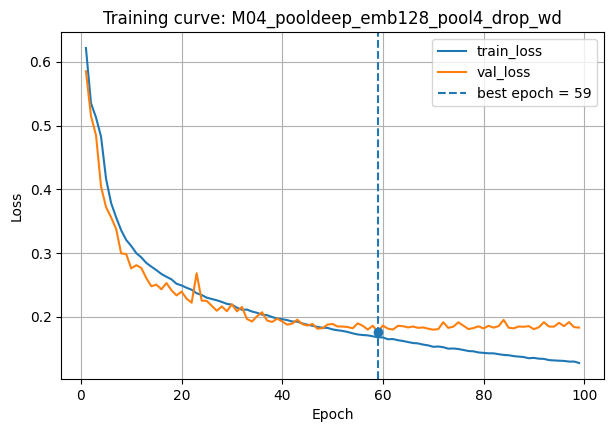

Best epoch:        59
Best val loss:     0.176160
Train loss @ best: 0.167545
Gap @ best:        0.008614
Stop epoch:        99


In [41]:
SELECTED_MODEL_ID = "M04_pooldeep_emb128_pool4_drop_wd"

selected = model_files_df.query("model_id == @SELECTED_MODEL_ID")

if len(selected) == 0:
    raise ValueError(
        f"Model not found: {SELECTED_MODEL_ID}. "
        f"Available models: {model_files_df['model_id'].tolist()}"
    )

selected = selected.iloc[0]

if not selected["history_exists"]:
    raise FileNotFoundError(f"No history file found for {SELECTED_MODEL_ID}")

history_df = load_history_npz(selected["history_path"])

best_idx = history_df["val_loss"].astype(float).idxmin()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_val = float(history_df.loc[best_idx, "val_loss"])
train_at_best = float(history_df.loc[best_idx, "train_loss"])

plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.scatter([best_epoch], [best_val], zorder=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training curve: {SELECTED_MODEL_ID}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best epoch:        {best_epoch}")
print(f"Best val loss:     {best_val:.6f}")
print(f"Train loss @ best: {train_at_best:.6f}")
print(f"Gap @ best:        {best_val - train_at_best:.6f}")
print(f"Stop epoch:        {int(history_df['epoch'].iloc[-1])}")

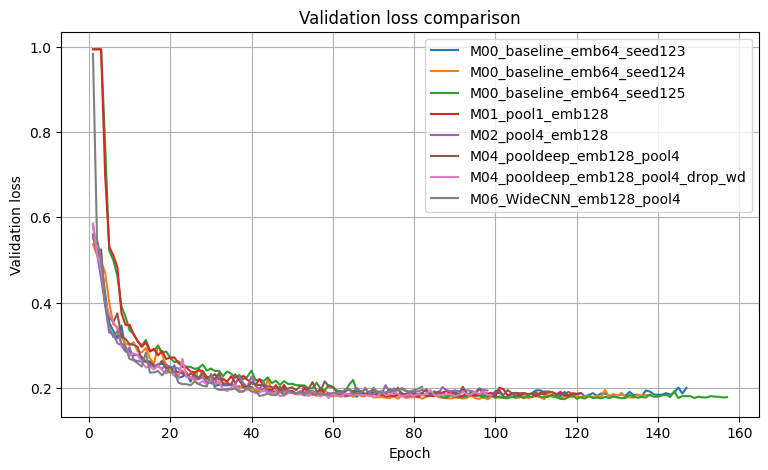

In [42]:
MODELS_TO_PLOT = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
    "M01_pool1_emb128",
    "M02_pool4_emb128",
    "M04_pooldeep_emb128_pool4",
    "M04_pooldeep_emb128_pool4_drop_wd",
    "M06_WideCNN_emb128_pool4",
]

available_model_ids = set(model_files_df["model_id"].tolist())

missing = [m for m in MODELS_TO_PLOT if m not in available_model_ids]

if missing:
    print("These requested models were not found:")
    for m in missing:
        print("  ", repr(m))

    print("\nAvailable model_ids are:")
    for m in sorted(available_model_ids):
        print("  ", repr(m))

plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        print(f"Skipping {model_id}: no history found")
        continue

    h = load_history_npz(selected["history_path"])

    plt.plot(h["epoch"], h["val_loss"], label=model_id)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss comparison")
plt.legend()
plt.grid(True)
plt.show()

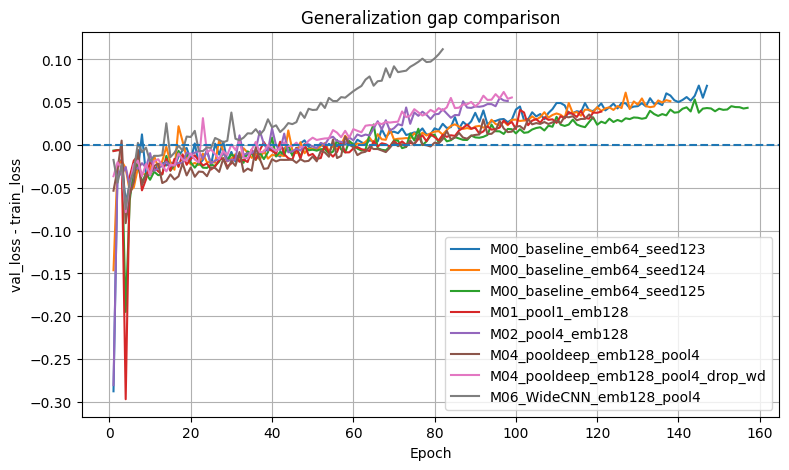

In [43]:
plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        continue

    h = load_history_npz(selected["history_path"])

    gap = h["val_loss"].astype(float) - h["train_loss"].astype(float)

    plt.plot(h["epoch"], gap, label=model_id)

plt.axhline(0.0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("val_loss - train_loss")
plt.title("Generalization gap comparison")
plt.legend()
plt.grid(True)
plt.show()
